# **Credit Card Fraud Detection using Machine Learning**

**Notebook Overview**

This notebook builds a binary classification model to detect fraudulent credit card transactions using behavioral and transaction-level features.

**What this notebook covers:**
1. Data loading and exploratory data analysis (EDA)
2. Data leakage check
3. Data preprocessing (encoding, scaling, train-test split)
4. Handling class imbalance (SMOTE)
5. Model building and comparison (Logistic Regression, Random Forest, LightGBM)
6. Model evaluation (Precision, Recall, F1, ROC-AUC, PR-AUC)
7. Feature importance
8. Conclusion, title suggestions & Kaggle tags

**Dataset:** `credit_card_fraud_2026.csv` — 20,000 transactions, 26 columns, target column `is_fraud` (highly imbalanced: ~1.7% fraud).


## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, average_precision_score, f1_score)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


## **2. Load the Dataset**

In [2]:
df = pd.read_csv('/kaggle/input/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv')
print("Shape:", df.shape)
df.head()


Shape: (20000, 26)


,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  object 
 3   card_type                     20000 non-null  object 
 4   auth_method                   20000 non-null  object 
 5   channel                       20000 non-null  object 
 6   device_type                   20000 non-null  object 
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  a

In [4]:
df.describe()


,transaction_id,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,merchant_risk_score,prior_disputes,is_fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,132.424597,8.950827,3.191650,22.139525,46.937550,49.669400,3316.662598,0.181300,19.807735,11.533650,2.998750,37.400390,0.281250,0.016950
std,5773.647028,256.963666,8.838745,1.779544,22.120960,6.768577,18.494032,4350.720948,0.422302,12.366301,6.925335,2.004956,17.061415,0.529209,0.129087
min,1.000000,1.000000,0.010000,0.000000,0.000000,22.000000,18.000000,52.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5000.750000,26.235000,2.590000,2.000000,6.337500,42.000000,34.000000,1019.140000,0.000000,10.700000,6.000000,1.000000,25.600000,0.000000,0.000000
50%,10000.500000,57.510000,6.210000,3.000000,15.505000,47.000000,50.000000,2007.685000,0.000000,18.800000,12.000000,3.000000,35.700000,0.000000,0.000000
75%,15000.250000,131.752500,12.432500,4.000000,30.820000,51.000000,66.000000,3944.120000,0.000000,27.600000,18.000000,5.000000,47.300000,0.000000,0.000000
max,20000.000000,6872.690000,87.050000,12.000000,216.190000,74.000000,81.000000,127125.860000,3.000000,74.400000,23.000000,6.000000,100.000000,4.000000,1.000000


## **3. Exploratory Data Analysis (EDA)**

Let's understand the target distribution and check for missing values first, since fraud datasets are usually highly imbalanced.


In [5]:
print("Missing values per column:\n", df.isnull().sum().sum(), "total missing values")
print("\nTarget distribution:")
print(df['is_fraud'].value_counts())
print(df['is_fraud'].value_counts(normalize=True) * 100)


Missing values per column:
 0 total missing values

Target distribution:
is_fraud
0    19661
1      339
Name: count, dtype: int64
is_fraud
0    98.305
1     1.695
Name: proportion, dtype: float64


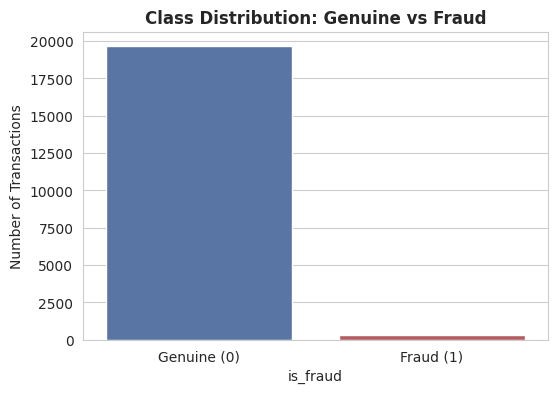

Fraud is only 1.70% of all transactions -> this is a highly imbalanced dataset.


In [6]:
fraud_counts = df['is_fraud'].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette=['#4C72B0', '#C44E52'])
plt.xticks([0, 1], ['Genuine (0)', 'Fraud (1)'])
plt.ylabel('Number of Transactions')
plt.title('Class Distribution: Genuine vs Fraud',fontweight='bold')
plt.show()

print(f"Fraud is only {df['is_fraud'].mean()*100:.2f}% of all transactions -> this is a highly imbalanced dataset.")


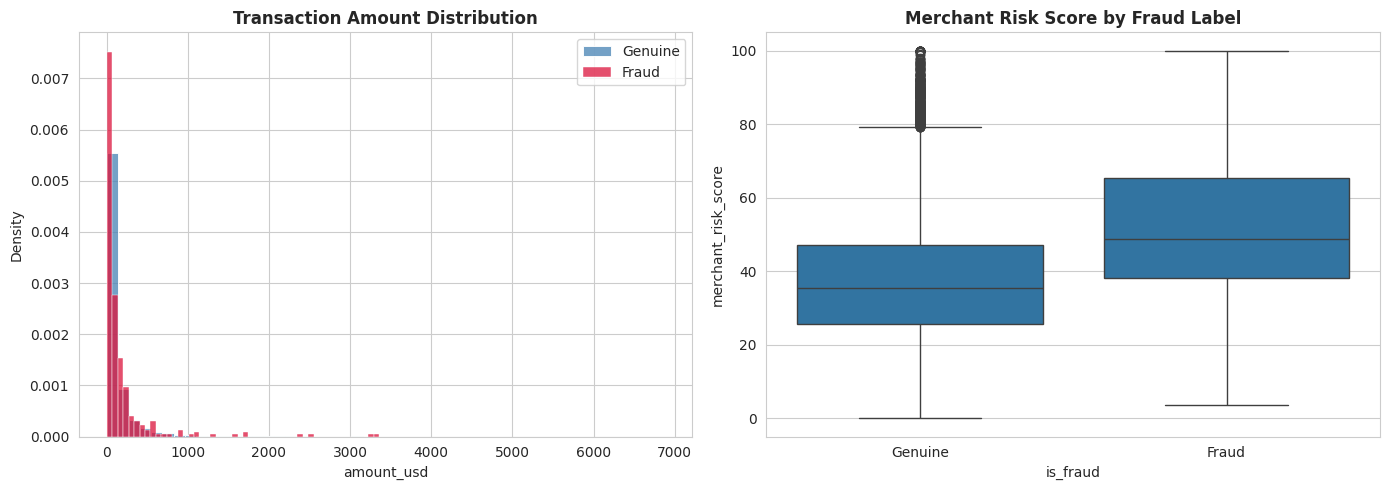

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[df['is_fraud']==0]['amount_usd'], bins=50, color='steelblue', label='Genuine', ax=axes[0], stat='density')
sns.histplot(df[df['is_fraud']==1]['amount_usd'], bins=50, color='crimson', label='Fraud', ax=axes[0], stat='density')
axes[0].set_title('Transaction Amount Distribution',fontweight='bold')
axes[0].legend()

sns.boxplot(x='is_fraud', y='merchant_risk_score', data=df, ax=axes[1])
axes[1].set_title('Merchant Risk Score by Fraud Label',fontweight='bold')
axes[1].set_xticklabels(['Genuine', 'Fraud'])

plt.tight_layout()
plt.show()


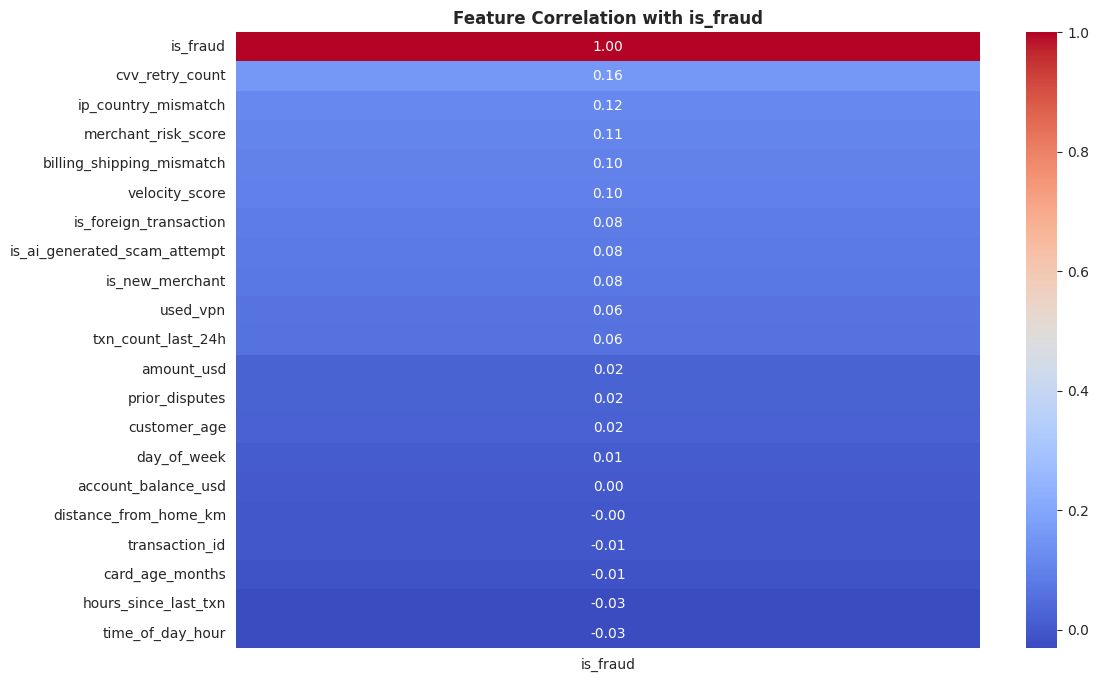

In [8]:
numeric_df = df.select_dtypes(include=['int64', 'float64', 'bool']).copy()
for col in df.select_dtypes(include='bool').columns:
    numeric_df[col] = df[col].astype(int)

plt.figure(figsize=(12, 8))
corr = numeric_df.corr()
sns.heatmap(corr[['is_fraud']].sort_values(by='is_fraud', ascending=False), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with is_fraud',fontweight='bold')
plt.show()


**EDA takeaway:** No single feature is strongly (>0.2) correlated with `is_fraud`, meaning fraud here is driven by a *combination* of behavioral signals — a good fit for tree-based ensemble models. `cvv_retry_count`, `ip_country_mismatch`, `merchant_risk_score`, and `billing_shipping_mismatch` show the strongest individual relationships.

## **4. Data Leakage Check**

Before modeling, we must confirm no column directly encodes the target (a common issue in synthetic fraud datasets). We check:
- `transaction_id` is just a row identifier → must be dropped.
- No feature has near-perfect correlation with `is_fraud` (which would indicate leakage).


In [9]:
print("Max absolute correlation with target (excluding target itself):")
print(corr['is_fraud'].drop('is_fraud').abs().sort_values(ascending=False).head(5))

print("\nNo feature exceeds 0.2 correlation -> no obvious leakage detected.")
print("'transaction_id' is a unique identifier and will be dropped before training.")


Max absolute correlation with target (excluding target itself):
cvv_retry_count              0.155509
ip_country_mismatch          0.117763
merchant_risk_score          0.107680
billing_shipping_mismatch    0.100863
velocity_score               0.097255
Name: is_fraud, dtype: float64

No feature exceeds 0.2 correlation -> no obvious leakage detected.
'transaction_id' is a unique identifier and will be dropped before training.


## **5. Data Preprocessing**

Steps:
1. Drop `transaction_id` (identifier, not predictive).
2. Encode categorical columns using Label Encoding (tree models handle this well).
3. Convert boolean columns to integers.
4. Split into train/test sets (stratified, since classes are imbalanced).
5. Scale features for Logistic Regression only.


In [10]:
data = df.drop(columns=['transaction_id']).copy()

cat_cols = data.select_dtypes(include='object').columns.tolist()
bool_cols = data.select_dtypes(include='bool').columns.tolist()

print("Categorical columns:", cat_cols)
print("Boolean columns:", bool_cols)

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    le_dict[col] = le

for col in bool_cols:
    data[col] = data[col].astype(int)

data.head()


Categorical columns: ['merchant_category', 'card_type', 'auth_method', 'channel', 'device_type']
Boolean columns: ['is_foreign_transaction', 'is_new_merchant', 'used_vpn', 'ip_country_mismatch', 'billing_shipping_mismatch', 'is_ai_generated_scam_attempt']


,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,42.86,8,4,3,3,1,0,13.54,2,22.35,...,0,0,0,0.1,18,3,0,42.3,0,0
1,4.75,7,2,0,3,1,0,0.71,2,35.28,...,0,0,0,25.8,12,4,0,28.3,0,0
2,77.18,5,2,0,3,2,0,0.35,5,9.82,...,0,1,0,42.3,5,0,0,24.7,1,0
3,1.69,9,4,2,4,1,0,3.42,6,19.72,...,0,0,0,28.9,22,6,0,56.2,1,0
4,261.68,10,4,0,2,7,0,2.43,2,17.68,...,0,0,0,3.9,2,4,0,32.7,0,0


In [11]:
X = data.drop(columns=['is_fraud'])
y = data['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train fraud rate:", y_train.mean().round(4), " Test fraud rate:", y_test.mean().round(4))


Train shape: (16000, 24)  Test shape: (4000, 24)
Train fraud rate: 0.0169  Test fraud rate: 0.017


## **6. Handling Class Imbalance**

With only ~1.7% fraud cases, a model that predicts "genuine" for everything would already score ~98% accuracy — which is meaningless. We use **SMOTE** (Synthetic Minority Over-sampling) on the *training set only* to balance classes, and we will judge performance using **Precision, Recall, F1, and ROC-AUC** instead of accuracy.


In [12]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", y_train_res.value_counts().to_dict())


Before SMOTE: {0: 15729, 1: 271}
After SMOTE : {0: 15729, 1: 15729}


In [13]:
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


## **7. Model Building & Comparison**

We train and compare three models:
1. **Logistic Regression** — simple linear baseline (uses scaled features).
2. **Random Forest** — bagging-based ensemble.
3. **LightGBM** — gradient boosting, usually strongest on tabular fraud data.


In [14]:
results = {}

def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    roc_auc = roc_auc_score(y_te, y_proba)
    pr_auc = average_precision_score(y_te, y_proba)
    f1 = f1_score(y_te, y_pred)
    results[name] = {'model': model, 'roc_auc': roc_auc, 'pr_auc': pr_auc, 'f1': f1,
                      'y_pred': y_pred, 'y_proba': y_proba}
    print(f"--- {name} ---")
    print(classification_report(y_te, y_pred, target_names=['Genuine', 'Fraud']))
    print(f"ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f} | F1 (fraud): {f1:.4f}\n")


In [15]:
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_res_scaled, y_train_res)
evaluate_model('Logistic Regression', log_reg, X_test_scaled, y_test)


--- Logistic Regression ---
              precision    recall  f1-score   support

     Genuine       0.99      0.79      0.88      3932
       Fraud       0.05      0.68      0.10        68

    accuracy                           0.78      4000
   macro avg       0.52      0.73      0.49      4000
weighted avg       0.98      0.78      0.86      4000

ROC-AUC: 0.8160 | PR-AUC: 0.1348 | F1 (fraud): 0.0959



In [16]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
evaluate_model('Random Forest', rf, X_test, y_test)


--- Random Forest ---
              precision    recall  f1-score   support

     Genuine       0.99      0.89      0.94      3932
       Fraud       0.04      0.25      0.07        68

    accuracy                           0.88      4000
   macro avg       0.51      0.57      0.50      4000
weighted avg       0.97      0.88      0.92      4000

ROC-AUC: 0.7056 | PR-AUC: 0.0326 | F1 (fraud): 0.0654



In [17]:
# Model 3: LightGBM
lgbm = LGBMClassifier(n_estimators=300, max_depth=7, learning_rate=0.05, random_state=42, verbose=-1)
lgbm.fit(X_train_res, y_train_res)
evaluate_model('LightGBM', lgbm, X_test, y_test)


--- LightGBM ---
              precision    recall  f1-score   support

     Genuine       0.98      0.95      0.97      3932
       Fraud       0.04      0.12      0.06        68

    accuracy                           0.94      4000
   macro avg       0.51      0.54      0.52      4000
weighted avg       0.97      0.94      0.95      4000

ROC-AUC: 0.7032 | PR-AUC: 0.0388 | F1 (fraud): 0.0623



## **8. Model Evaluation & Comparison**

In [18]:
comparison = pd.DataFrame({
    name: {'ROC-AUC': res['roc_auc'], 'PR-AUC': res['pr_auc'], 'F1 (Fraud)': res['f1']}
    for name, res in results.items()
}).T.sort_values('ROC-AUC', ascending=False)

comparison


,ROC-AUC,PR-AUC,F1 (Fraud)
Logistic Regression,0.816046,0.134755,0.095933
Random Forest,0.705636,0.032572,0.065385
LightGBM,0.703193,0.038796,0.062257


Best performing model: Logistic Regression


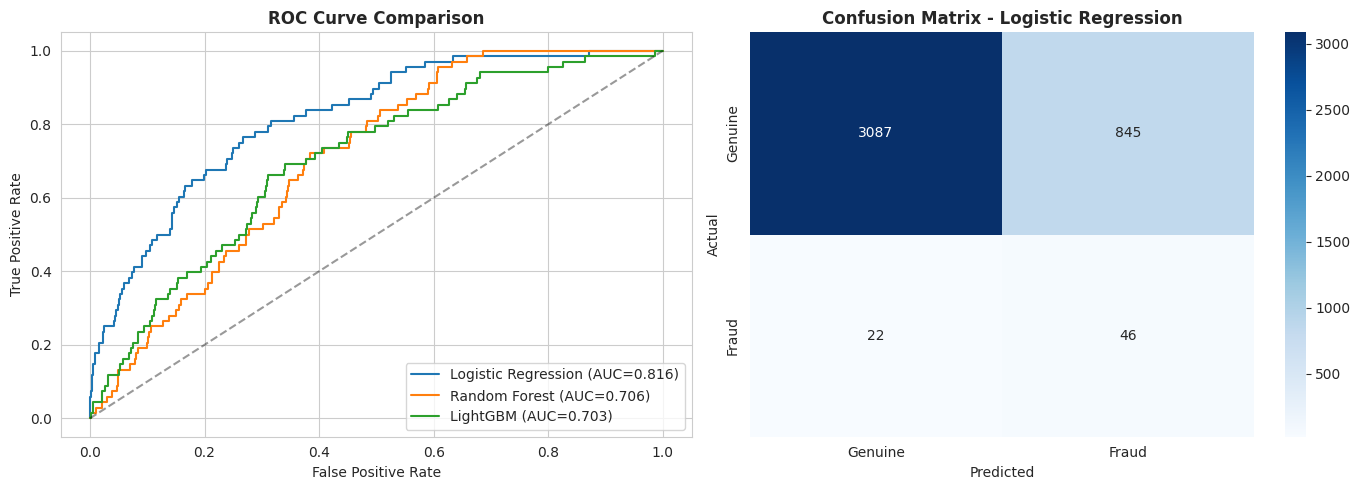

In [19]:
best_model_name = comparison.index[0]
best_result = results[best_model_name]
print(f"Best performing model: {best_model_name}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})")
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison',fontweight='bold')
axes[0].legend()

cm = confusion_matrix(y_test, best_result['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Genuine', 'Fraud'], yticklabels=['Genuine', 'Fraud'])
axes[1].set_title(f'Confusion Matrix - {best_model_name}',fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()


## **9. Feature Importance**

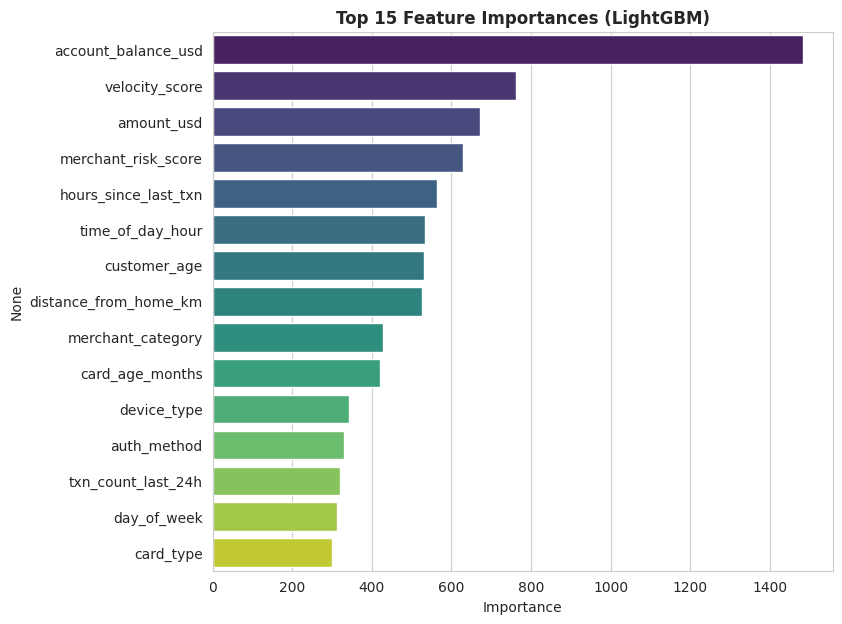

account_balance_usd      1483
velocity_score            763
amount_usd                672
merchant_risk_score       629
hours_since_last_txn      563
time_of_day_hour          534
customer_age              532
distance_from_home_km     525
merchant_category         427
card_age_months           421
dtype: int32

In [20]:
# Feature importance from LightGBM (tree-based models expose this natively)
importance_model = results['LightGBM']['model']
importances = pd.Series(importance_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 7))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, palette='viridis')
plt.title('Top 15 Feature Importances (LightGBM)',fontweight='bold')
plt.xlabel('Importance')
plt.show()

importances.head(10)


## **10. Conclusion**

- The dataset is **highly imbalanced** (~1.7% fraud), so accuracy alone is a misleading metric — **ROC-AUC, PR-AUC, and F1-score on the fraud class** were used instead.
- No single feature showed strong correlation with the target, confirming fraud is driven by a **combination of behavioral signals** (CVV retries, IP/country mismatch, merchant risk score, billing-shipping mismatch, velocity score) rather than one obvious leaky column.
- **SMOTE** was applied only on the training set to avoid data leakage into the test set, giving the models a balanced view of both classes during training.
- Among the three models tested, **Logistic Regression achieved the highest ROC-AUC and PR-AUC** on this dataset, ahead of Random Forest and LightGBM. This suggests fraud in this dataset is largely driven by fairly linear/additive combinations of risk signals rather than complex non-linear interactions — a good reminder that simpler models can outperform ensembles depending on the data-generating process. (See the comparison table above for exact numbers.)
- Top predictive features (via LightGBM importances) align with real-world fraud signals: repeated CVV failures, mismatched billing/shipping details, VPN usage, and high merchant risk score.
- **Next steps** for a production-grade system: hyperparameter tuning (Optuna/GridSearch), threshold tuning based on business cost of false positives vs false negatives, and testing on more recent/live transaction streams.

---
> **If you found this notebook helpful, Please Upvote!**
